# Import Necessary Libraries

In [2]:
import os
import sys
import warnings

project_root = os.path.abspath("../..")
print(f"Project root: {project_root}")

# Add project_root to sys.path
if project_root not in sys.path:
    sys.path.append(project_root)
warnings.simplefilter("ignore")

Project root: /data/home/hadi/RT-TR


In [3]:
import argparse
import warnings
from functools import partial

import matplotlib.pyplot as plt
import pandas as pd
import torch
from net.net import LSTMClassificationHead, RobertaForRegression
from rdkit import Chem
from rdkit.Chem import Draw
from safetensors.torch import load_file
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import (
    PowerTransformer,
)
from transformers import (
    AutoConfig,
    AutoTokenizer,
)
from utils.dataset import SMILESDataset
from utils.metrics import compute_metrics
from utils.plotting import (
    plot_attention_heatmap,
    plot_attention_on_sequence,
    visualize_attention,
    visualize_molecule_with_colorbar,
)
from utils.utils import (
    expand_tokens_and_scores,
    get_attention_maps,
    seed_torch,
)

# Initialize the model from the pretrained model

In [4]:
parser = argparse.ArgumentParser(description="Train a model ....")
parser.add_argument("--model_name", type=str, default="roberta", help="model name")
parser.add_argument(
    "--path",
    type=str,
    default="/data/home/hadi/test/_runs/2023_12_29",
    help="path to the saved model",
)

args = parser.parse_args("")
seed = 1
seed_torch(seed)
# %%
save_model_path = "/data/home/hadi/test/models/ChemBERTa-zinc-base-v1"
# checkpoint = "DeepChem/SmilesTokenizer_PubChem_1M" PubChem10M_SMILES_BPE_450k SMILES_tokenized_PubChem_shard00_160k
tokenizer = AutoTokenizer.from_pretrained(save_model_path)
config = AutoConfig.from_pretrained(save_model_path)

model = RobertaForRegression.from_pretrained(
    save_model_path,
    num_labels=1,
    ignore_mismatched_sizes=True,
    last_use=False,
    weighted=False,
    layers_to_use=[-1, -3, -5],
    use_lora=False,
)

model.classifier = LSTMClassificationHead(
    hidden_dim=768 * 3,
    lstm_hidden_size=768,
    num_labels=1,
    feature_method="mean",
    lstm_layers=1,
    dropout=0.1,
    bidirectional=True,
    skip=False,
    cls_skip=False,
    out_conv=None,
)

best_checkpoint = "/data/home/hadi/RT-TR/models/best_checkpoint/checkpoint-380982/model.safetensors"
model.load_state_dict(load_file(best_checkpoint))

df = pd.read_csv("/data/home/hadi/test/data/SMRT_dataset_com.txt", sep="\t")
df_n, df_test = train_test_split(df, test_size=0.1, random_state=seed)
df_train, df_val = train_test_split(df_n, test_size=0.1, random_state=seed)
df_train.reset_index(drop=True, inplace=True)
df_val.reset_index(drop=True, inplace=True)
df_test.reset_index(drop=True, inplace=True)

numeric_columns = ["rt"]

scaler = PowerTransformer(method="box-cox", standardize=True)

df_train[numeric_columns] = scaler.fit_transform(df_train[numeric_columns])
df_test[numeric_columns] = scaler.transform(df_test[numeric_columns])
df_val[numeric_columns] = scaler.transform(df_val[numeric_columns])

compute_metrics = partial(compute_metrics, scaler=scaler)

test_dataset = SMILESDataset(
    df_test,
    "smiles",
    "rt",
    tokenizer,
    max_length=89,
    augment=False,
    add_special_tokens=False,
)

Some weights of RobertaForRegression were not initialized from the model checkpoint at /data/home/hadi/test/models/ChemBERTa-zinc-base-v1 and are newly initialized: ['classifier.head.0.bias', 'classifier.head.0.weight', 'classifier.head.3.bias', 'classifier.head.3.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


# Visualize attention weights in Transformer model

In [5]:
# tokens = ["O", "=", "CCN"]
# scores = [0.1, 0.2, 0.3]
# print("".join(tokens))
# expanded_tokens, expanded_scores = expand_tokens_and_scores(tokens, scores)
# print(expanded_tokens)
# # print(expanded_scores)

# visualize_molecule_with_colorbar(expanded_tokens, expanded_scores)


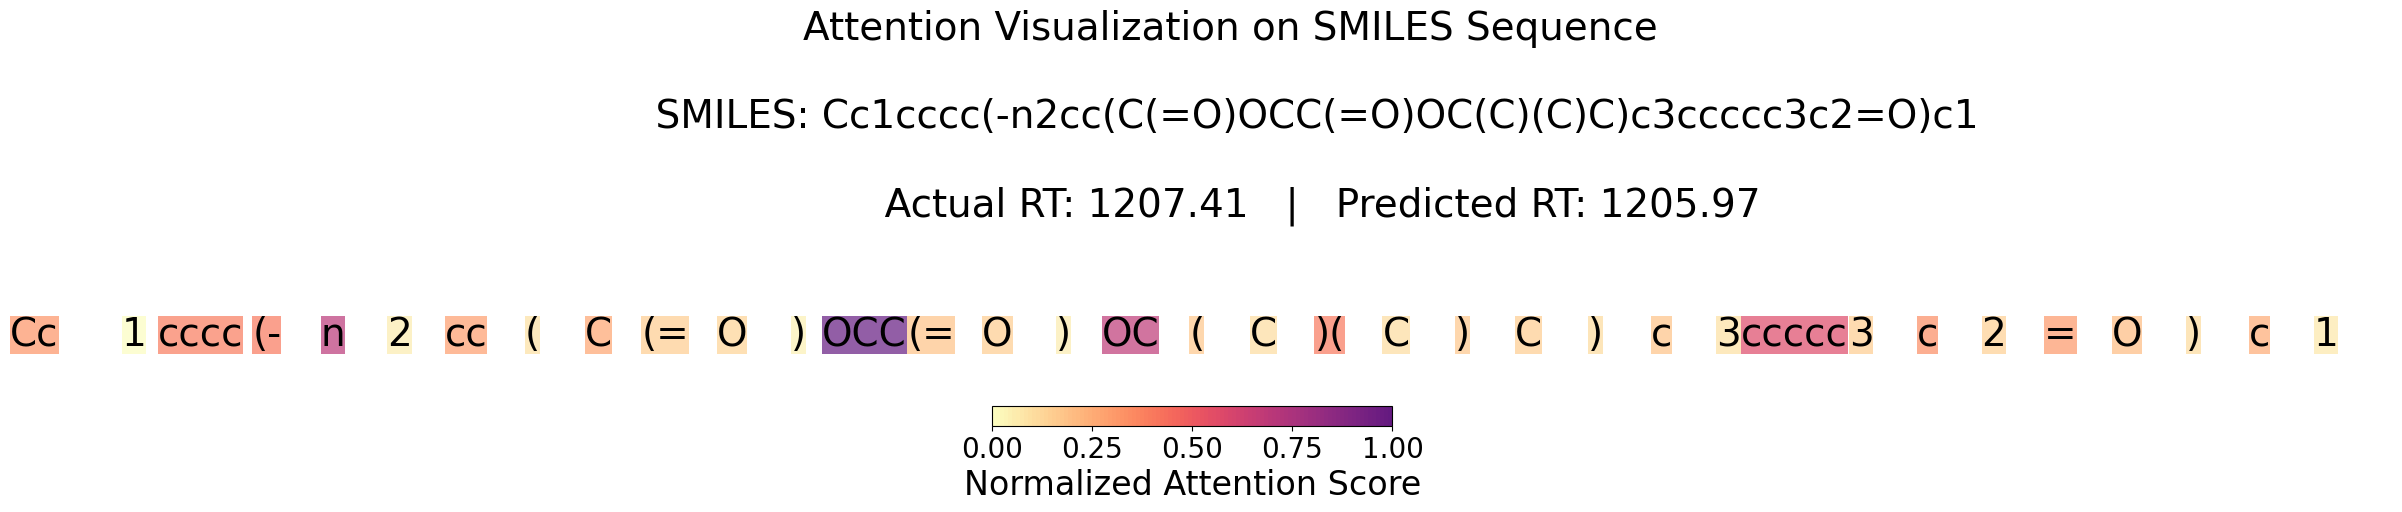

Actual RT: 1207.4064 Predicted RT: 1205.9656
smiles Cc1cccc(-n2cc(C(=O)OCC(=O)OC(C)(C)C)c3ccccc3c2=O)c1
tokens ['Cc', '1', 'cccc', '(-', 'n', '2', 'cc', '(', 'C', '(=', 'O', ')', 'OCC', '(=', 'O', ')', 'OC', '(', 'C', ')(', 'C', ')', 'C', ')', 'c', '3', 'ccccc', '3', 'c', '2', '=', 'O', ')', 'c', '1']
score [0.32565945, 0.0, 0.39051214, 0.40731674, 0.6919282, 0.051134124, 0.29004866, 0.091336966, 0.27542907, 0.15742385, 0.13950796, 0.043102358, 1.0, 0.18705137, 0.15184274, 0.05958006, 0.6839586, 0.17089964, 0.10307745, 0.40508103, 0.10698203, 0.17779188, 0.15303223, 0.11810425, 0.18621741, 0.09960171, 0.5770168, 0.1589935, 0.34550774, 0.14865185, 0.31250125, 0.20449135, 0.116797596, 0.2593769, 0.07969786]


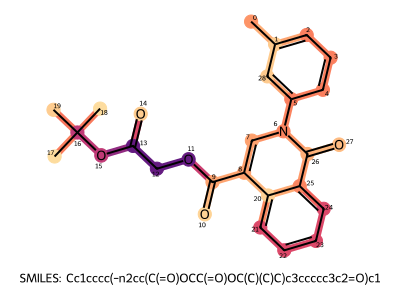

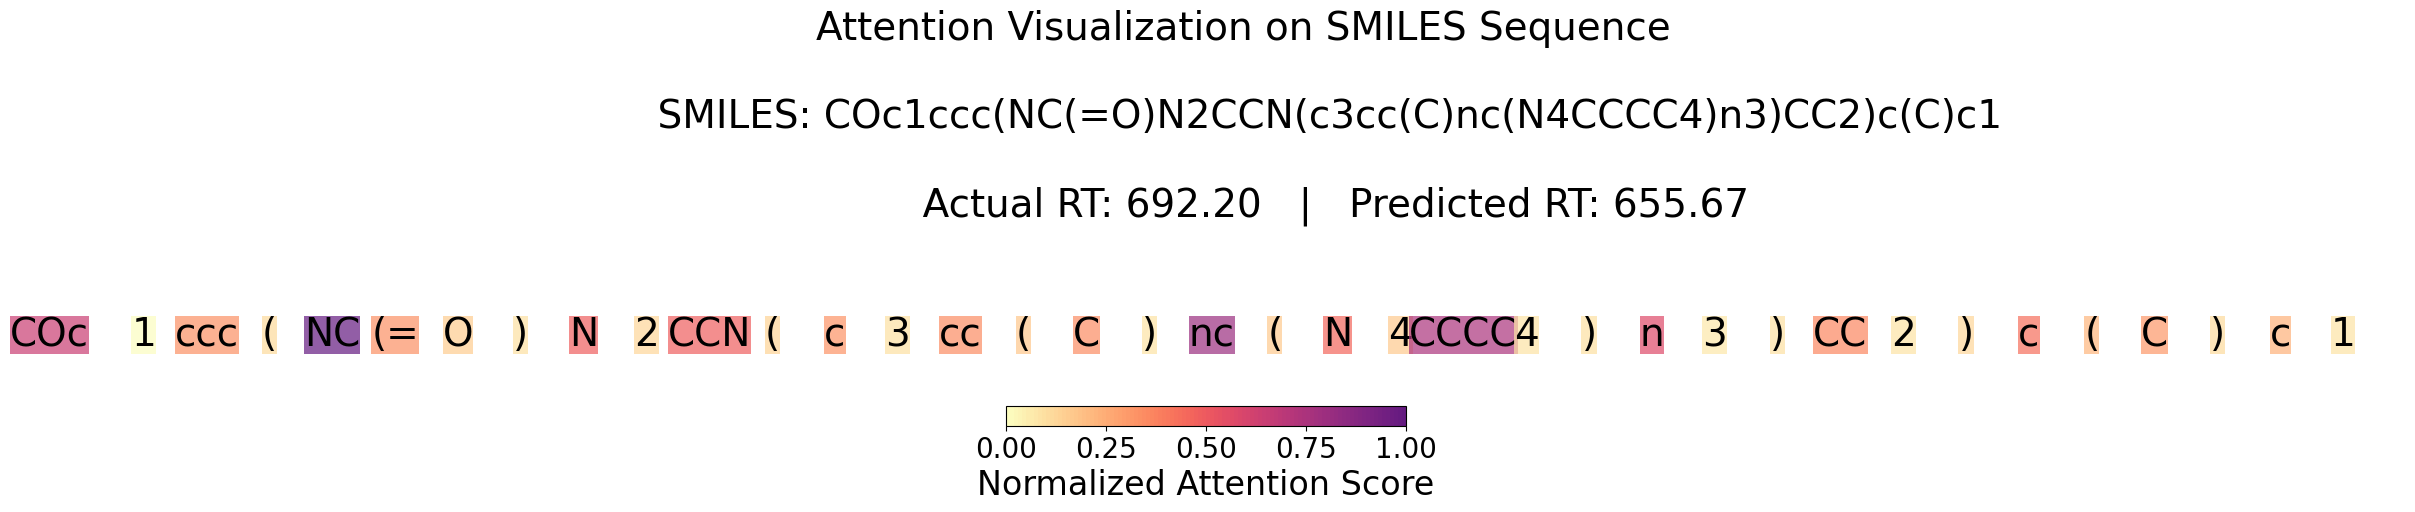

Actual RT: 692.2033 Predicted RT: 655.67377
smiles COc1ccc(NC(=O)N2CCN(c3cc(C)nc(N4CCCC4)n3)CC2)c(C)c1
tokens ['COc', '1', 'ccc', '(', 'NC', '(=', 'O', ')', 'N', '2', 'CCN', '(', 'c', '3', 'cc', '(', 'C', ')', 'nc', '(', 'N', '4', 'CCCC', '4', ')', 'n', '3', ')', 'CC', '2', ')', 'c', '(', 'C', ')', 'c', '1']
score [0.6422217, 0.0, 0.33635902, 0.11652478, 1.0, 0.33898994, 0.15585037, 0.094373725, 0.48815167, 0.12622112, 0.48505968, 0.13313921, 0.32217133, 0.09395209, 0.34486285, 0.1784083, 0.34394556, 0.08175151, 0.80120254, 0.16998996, 0.46152154, 0.16740873, 0.7499985, 0.081962556, 0.0979067, 0.5700986, 0.0763891, 0.090731636, 0.36155093, 0.08494665, 0.12307738, 0.4325134, 0.2262888, 0.3100089, 0.111250184, 0.23437564, 0.08253769]


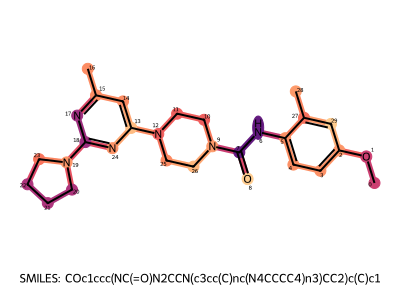

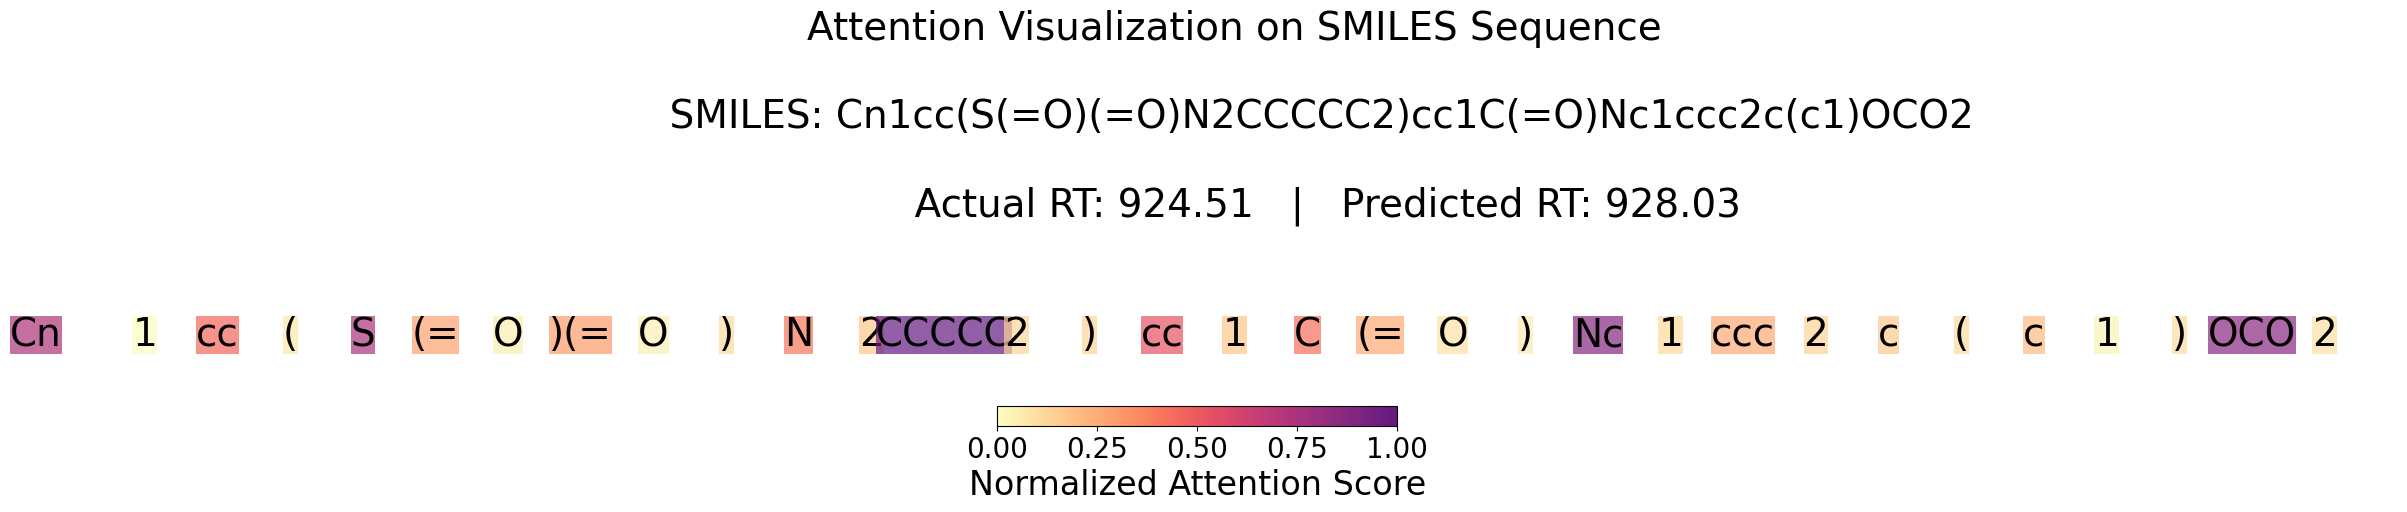

Actual RT: 924.5097 Predicted RT: 928.0332
smiles Cn1cc(S(=O)(=O)N2CCCCC2)cc1C(=O)Nc1ccc2c(c1)OCO2
tokens ['Cn', '1', 'cc', '(', 'S', '(=', 'O', ')(=', 'O', ')', 'N', '2', 'CCCCC', '2', ')', 'cc', '1', 'C', '(=', 'O', ')', 'Nc', '1', 'ccc', '2', 'c', '(', 'c', '1', ')', 'OCO', '2']
score [0.73299485, 0.0, 0.46041846, 0.07238327, 0.74003536, 0.28988212, 0.042749897, 0.30684522, 0.04728013, 0.11760711, 0.41468436, 0.17966984, 1.0, 0.121694945, 0.13379057, 0.5257353, 0.17601587, 0.4321061, 0.26897317, 0.08002793, 0.057962455, 0.8758089, 0.11127595, 0.26580846, 0.13969281, 0.16477041, 0.11473424, 0.20458533, 0.038904812, 0.109450154, 0.86807853, 0.09695754]


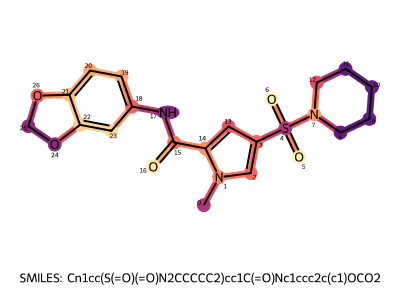

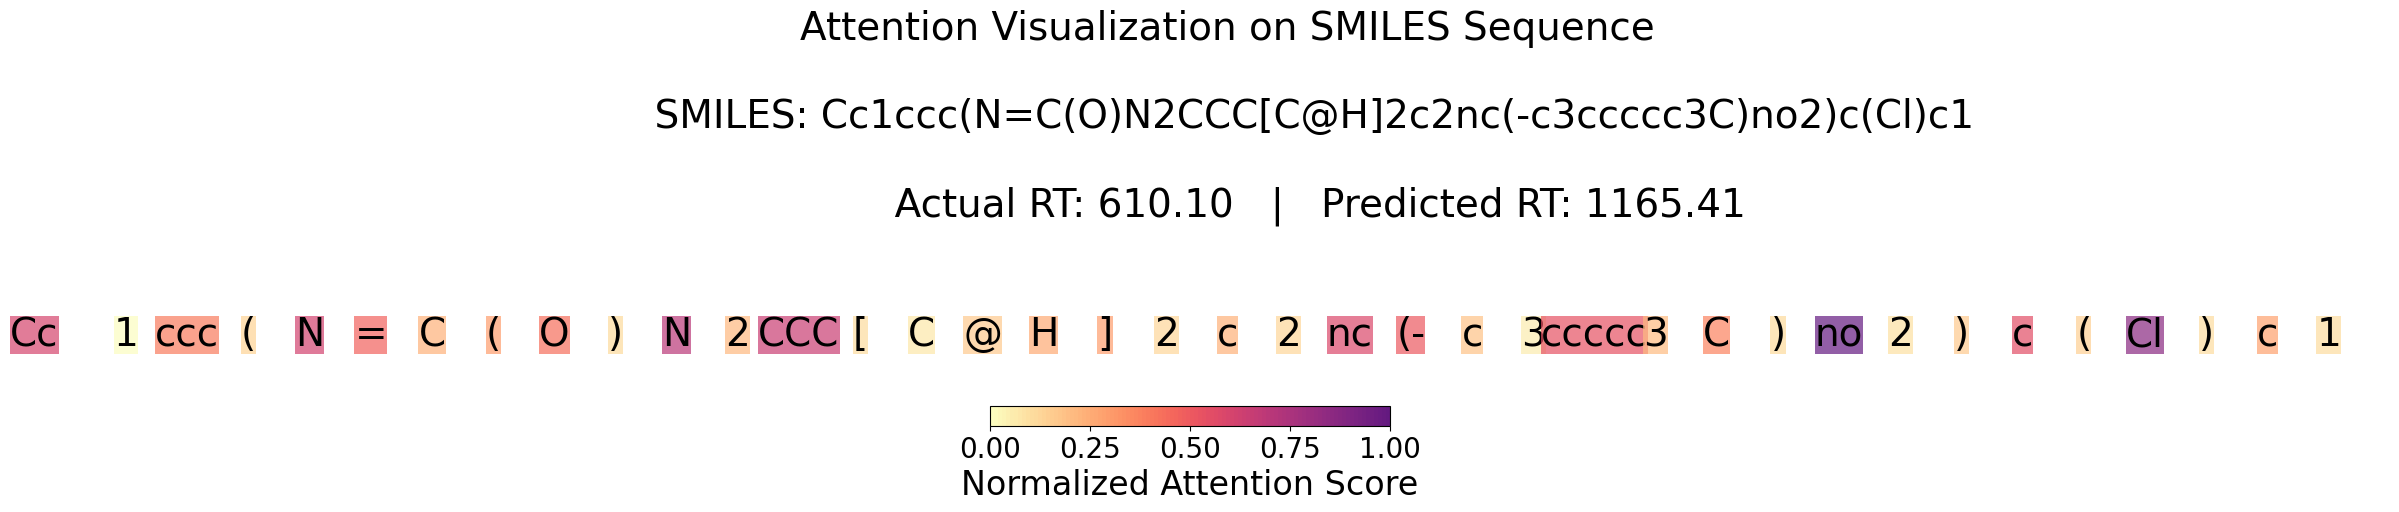

Actual RT: 610.10297 Predicted RT: 1165.4083
smiles Cc1ccc(N=C(O)N2CCC[C@H]2c2nc(-c3ccccc3C)no2)c(Cl)c1
tokens ['Cc', '1', 'ccc', '(', 'N', '=', 'C', '(', 'O', ')', 'N', '2', 'CCC', '[', 'C', '@', 'H', ']', '2', 'c', '2', 'nc', '(-', 'c', '3', 'ccccc', '3', 'C', ')', 'no', '2', ')', 'c', '(', 'Cl', ')', 'c', '1']
score [0.6022227, 0.0, 0.39290544, 0.13104483, 0.6130828, 0.47720927, 0.23904063, 0.2946373, 0.43923885, 0.11502944, 0.69369596, 0.21790148, 0.64433485, 0.10759247, 0.070136994, 0.16877462, 0.25278214, 0.2973907, 0.12415977, 0.23687758, 0.12652731, 0.5867074, 0.5003746, 0.18444419, 0.05753116, 0.5302554, 0.2012327, 0.3750025, 0.11229371, 1.0, 0.090540305, 0.16213433, 0.5533124, 0.14300069, 0.86351043, 0.10974914, 0.2880714, 0.106236614]


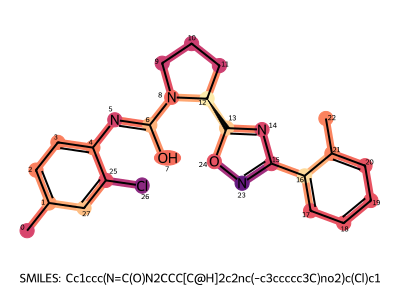

In [ ]:
# Example SMILES strings
# [6628, 4411, 2122, 4222, 5977, 667]
# [ 36, 65, 550, 667]
smiles_examples = [36, 65, 550, 667]

# Generate and plot visualizations for each SMILES string
for smiles in smiles_examples:
    attention_weights, tokens, attentions, actual, predicted = get_attention_maps(
        model, tokenizer, smiles, scaler, test_dataset, layers=[0, 1, 2, 3, 4, 5]
    )
    smiles = df_test.iloc[smiles]["smiles"]
    mol = Chem.MolFromSmiles(smiles)

    # # Plot heatmap
    # fig_heatmap = plot_attention_heatmap(smiles, attention_weights, tokens)
    # plt.figure(fig_heatmap.number)
    # plt.show()
    # Plot attention on sequence
    fig_sequence = plot_attention_on_sequence(
        smiles,
        attention_weights,
        tokens,
        actual,
        predicted,
        "../../figures/figure_attention",
    )
    plt.figure(fig_sequence.number)
    plt.show()

    # Draw molecule
    draw = Draw.MolToImage(mol)
    # Aggregate attention weights
    agg_attention = attention_weights.mean(axis=0)

    # Normalize attention weights
    norm_attention = (agg_attention - agg_attention.min()) / (agg_attention.max() - agg_attention.min())
    print("Actual RT:", actual, "Predicted RT:", predicted)
    print("smiles", "".join(tokens))
    print("tokens", tokens)
    print("score", list(norm_attention))

    expanded_tokens, expanded_scores = expand_tokens_and_scores(tokens, norm_attention)
    # make dict of atom indices and corresponding scores
    visualize_molecule_with_colorbar(expanded_tokens, expanded_scores)

    a = torch.cat(attentions)[:, :, : len(tokens), : len(tokens)]
    # visualize_attention(a)

# TODO: add attention to the model

In [ ]:
# # ethyl (4R)-6-[(4-ethoxycarbonylpiperidin-1-yl)methyl]-4-(4-fluorophenyl)-2-oxo-3,4-dihydro-1H-pyrimidine-5-carboxylate

# # 2-(tert-butoxy)-2-oxoethyl 1-oxo-2-(m-tolyl)-1,2-dihydroisoquinoline-4-carboxylate
# tert-butyl 2-[2-(3-methylphenyl)-1-oxo-1,2-dihydroisoquinoline-4-carbonyloxy]acetate
# [2-[(2-methylpropan-2-yl)oxy]-2-oxoethyl] 2-(3-methylphenyl)-1-oxoisoquinoline-4-carboxylate
# STL104495

# N-(4-METHOXY-2-METHYLPHENYL)-4-[6-METHYL-2-(PYRROLIDIN-1-YL)PYRIMIDIN-4-YL]PIPERAZINE-1-CARBOXAMIDE
# AKOS021914625

# (2S)-N-(2-chloro-4-methylphenyl)-2-[3-(2-methylphenyl)-1,2,4-oxadiazol-5-yl]pyrrolidine-1-carboxamide